In [1]:
import pandas as pd
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

connection_url = URL.create(
    "mysql+pymysql",
    username="root",
    password="Aditya@123",
    host="localhost",
    port=3306,
    database="retail_forecasting"
)

engine = create_engine(connection_url)

df = pd.read_sql("SELECT * FROM retail_sales", engine)

df["Date"] = pd.to_datetime(df["Date"])

df.head()

,Date,Store_ID,Product_ID,Category,Region,Inventory_Level,Units_Sold,Units_Ordered,Price,Discount,Weather_Condition,Promotion,Competitor_Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [2]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["Quarter"] = df["Date"].dt.quarter
df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)

df.head()

,Date,Store_ID,Product_ID,Category,Region,Inventory_Level,Units_Sold,Units_Ordered,Price,Discount,...,Competitor_Pricing,Seasonality,Epidemic,Demand,Year,Month,Day,DayOfWeek,Quarter,WeekOfYear
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,...,85.73,Winter,0,115,2022,1,1,5,1,52
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,...,92.02,Winter,0,229,2022,1,1,5,1,52
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,...,60.08,Winter,0,157,2022,1,1,5,1,52
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,...,85.19,Winter,0,52,2022,1,1,5,1,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,...,51.63,Winter,0,59,2022,1,1,5,1,52


In [3]:
df["Inventory_Turnover"] = df["Units_Sold"] / (df["Inventory_Level"] + 1)

df.head()

,Date,Store_ID,Product_ID,Category,Region,Inventory_Level,Units_Sold,Units_Ordered,Price,Discount,...,Seasonality,Epidemic,Demand,Year,Month,Day,DayOfWeek,Quarter,WeekOfYear,Inventory_Turnover
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,...,Winter,0,115,2022,1,1,5,1,52,0.520408
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,...,Winter,0,229,2022,1,1,5,1,52,0.991525
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,...,Winter,0,157,2022,1,1,5,1,52,0.459677
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,...,Winter,0,52,2022,1,1,5,1,52,0.321429
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,...,Winter,0,59,2022,1,1,5,1,52,0.424837


In [4]:
df["Discounted_Price"] = df["Price"] * (1 - df["Discount"] / 100)

df.head()

,Date,Store_ID,Product_ID,Category,Region,Inventory_Level,Units_Sold,Units_Ordered,Price,Discount,...,Epidemic,Demand,Year,Month,Day,DayOfWeek,Quarter,WeekOfYear,Inventory_Turnover,Discounted_Price
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,...,0,115,2022,1,1,5,1,52,0.520408,69.084
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,...,0,229,2022,1,1,5,1,52,0.991525,68.136
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,...,0,157,2022,1,1,5,1,52,0.459677,56.646
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,...,0,52,2022,1,1,5,1,52,0.321429,78.867
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,...,0,59,2022,1,1,5,1,52,0.424837,54.410


In [5]:
df_model = df.copy()

df_model = pd.get_dummies(
    df_model,
    columns=[
        "Category",
        "Region",
        "Weather_Condition",
        "Seasonality"
    ],
    drop_first=True
)

df_model.head()

,Date,Store_ID,Product_ID,Inventory_Level,Units_Sold,Units_Ordered,Price,Discount,Promotion,Competitor_Pricing,...,Category_Toys,Region_North,Region_South,Region_West,Weather_Condition_Rainy,Weather_Condition_Snowy,Weather_Condition_Sunny,Seasonality_Spring,Seasonality_Summer,Seasonality_Winter
0,2022-01-01,S001,P0001,195,102,252,72.72,5,0,85.73,...,False,True,False,False,False,True,False,False,False,True
1,2022-01-01,S001,P0002,117,117,249,80.16,15,1,92.02,...,False,True,False,False,False,True,False,False,False,True
2,2022-01-01,S001,P0003,247,114,612,62.94,10,1,60.08,...,False,True,False,False,False,True,False,False,False,True
3,2022-01-01,S001,P0004,139,45,102,87.63,10,0,85.19,...,False,True,False,False,False,True,False,False,False,True
4,2022-01-01,S001,P0005,152,65,271,54.41,0,0,51.63,...,False,True,False,False,False,True,False,False,False,True


In [6]:
df_model = df_model.drop(
    columns=[
        "Store_ID",
        "Product_ID",
        "Date"
    ]
)

df_model.head()

,Inventory_Level,Units_Sold,Units_Ordered,Price,Discount,Promotion,Competitor_Pricing,Epidemic,Demand,Year,...,Category_Toys,Region_North,Region_South,Region_West,Weather_Condition_Rainy,Weather_Condition_Snowy,Weather_Condition_Sunny,Seasonality_Spring,Seasonality_Summer,Seasonality_Winter
0,195,102,252,72.72,5,0,85.73,0,115,2022,...,False,True,False,False,False,True,False,False,False,True
1,117,117,249,80.16,15,1,92.02,0,229,2022,...,False,True,False,False,False,True,False,False,False,True
2,247,114,612,62.94,10,1,60.08,0,157,2022,...,False,True,False,False,False,True,False,False,False,True
3,139,45,102,87.63,10,0,85.19,0,52,2022,...,False,True,False,False,False,True,False,False,False,True
4,152,65,271,54.41,0,0,51.63,0,59,2022,...,False,True,False,False,False,True,False,False,False,True


In [7]:
X = df_model.drop("Demand", axis=1)
y = df_model["Demand"]

print(X.shape)
print(y.shape)

(76000, 29)
(76000,)


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(60800, 29)
(15200, 29)


In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, predictions))
print("RMSE:", mean_squared_error(y_test, predictions) ** 0.5)
print("R2 Score:", r2_score(y_test, predictions))

MAE: 12.820007894736841
RMSE: 17.065123443197795
R2 Score: 0.8681383922698488


               Feature  Importance
1           Units_Sold    0.714396
2        Units_Ordered    0.072047
0      Inventory_Level    0.045448
14  Inventory_Turnover    0.042835
3                Price    0.014831
6   Competitor_Pricing    0.013804
10                 Day    0.012191
15    Discounted_Price    0.010564
13          WeekOfYear    0.009109
7             Epidemic    0.007467


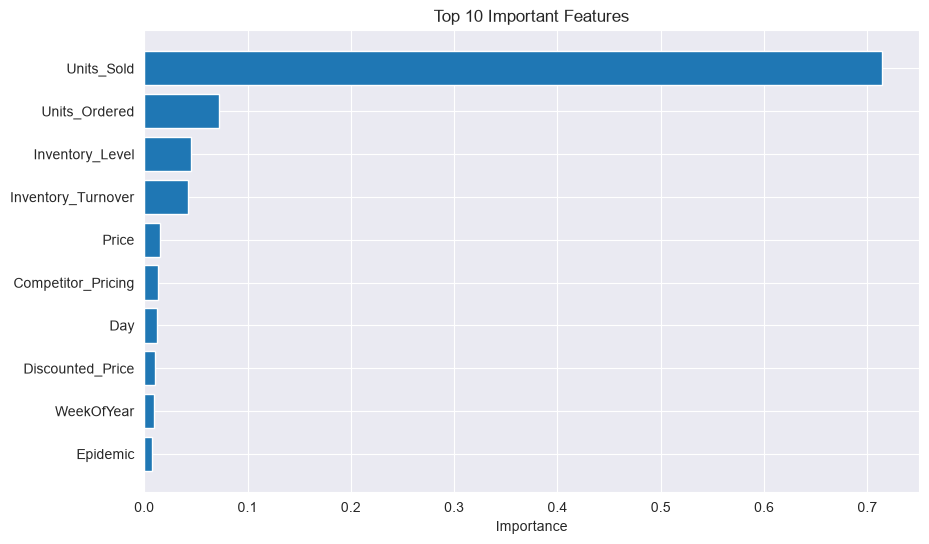

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

plt.figure(figsize=(10,6))
plt.barh(
    feature_importance["Feature"][:10],
    feature_importance["Importance"][:10]
)
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.show()

In [12]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
})

results.head(20)

,Actual,Predicted
0,111,102.74
1,81,80.84
2,37,39.27
3,152,162.89
4,101,94.37
5,137,139.56
6,127,144.82
7,163,118.00
8,164,133.14
9,111,111.73


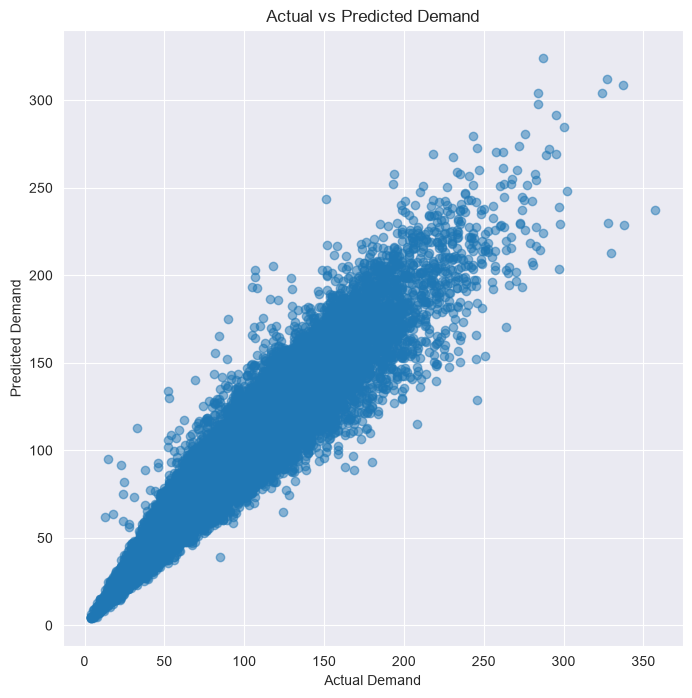

In [13]:
plt.figure(figsize=(8,8))
plt.scatter(y_test, predictions, alpha=0.5)

plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Actual vs Predicted Demand")

plt.show()

In [14]:
import joblib

joblib.dump(model, "../models/random_forest_model.pkl")

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


In [15]:
import joblib

joblib.dump(model, "../models/random_forest_model.pkl")
joblib.dump(X.columns.tolist(), "../models/model_columns.pkl")

print("Model and feature list saved successfully!")

Model and feature list saved successfully!
